# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import sys
sys.path.append("../utils")
from utils import *

In [3]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})

# AH map - base

In [4]:
# n, D, file_id
# comment out the ones not required
ah_index =[
    [0.465, 1.000, 1552],
    #[0.500, 1.025, 1554],
    [0.550, 1.035, 1556],
    #[0.600, 1.040, 1558],
    #[0.650, 1.046, 1560],
    [0.620, 1.020, 1562],
    [0.590, 1.000, 1564],
    [0.540, 0.975, 1566],
    [0.430, 0.950, 1568],
    #[0.385, 0.900, 1570],
    #[0.475, 0.940, 1572],
    [0.705, 1.025, 1574],
    [0.600, 0.940, 1576],
    #[0.450, 0.900, 1578],
    [0.360, 0.850, 1580],
    [0.450, 0.860, 1582],
    #[0.500, 0.900, 1584],
    #[0.650, 0.900, 1586],
]
markers = ['o', '^', 's', 'D', 'v', 'P', '*', 'X', 'h', 'p', '<', '>', 'H', 'd', '8', '+', 'x', '|']
marker_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [5]:
def guide_map(fig, ax, norm, cmap, ah_index, markers=markers, marker_colors=marker_colors):
    files= [1490, 1491, 1492, 1493]

    ns = np.array([0.45, 0.72, 0.8, 0.8, 0.28])
    Ds = np.array([1.04, 1.065, 1.058, 0.80, 0.80])

    nx, ny = 101, 101

    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)

    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)

    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)

    contact_pairs = {
        'curr': {'indices': [], 'norm': colors.Normalize(vmin=0, vmax=0.5), 'cmap': 'viridis', 'label': r'$I/I_0$'},
        'long1': {'indices': [], 'norm': colors.SymLogNorm(linthresh=10, vmin=0, vmax=3E4), 'cmap': 'viridis', 'label': r'$R_{xx}$ ($\Omega$)'},
        'fakehall': {'indices': [2], 'norm': norm, 'cmap': cmap, 'label': r'$R_{yx}$ ($\Omega$)'},
        'realhall': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
        'nl': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E2, vmax=1E2), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
    }

    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            
            zss = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=True)
                zss.append(zs)

            rxy100 = (zss[1] - zss[2])/2 # 100 mT
            rxy200 = (zss[0] - zss[3])/2 # 200 mT
            # zs_s = (zss[1] + zss[2])/2 - (zss[0] + zss[3])/4
            # zs_a = ((zss[1] - zss[2])/2 - (zss[0] - zss[3])/4)
            zs_a = (rxy100 - (1/2)*rxy200)*2
    
            plot = ax.pcolormesh(xs, ys, zs_a, norm=norm, cmap=cmap, rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')

            for i,(n,D,f) in enumerate(ah_index):
                ax.scatter(n, D, marker=markers[i % len(markers)], color=marker_colors[i % len(marker_colors)], s=80, zorder=3)
                #ax.plot(n, D, 'k.', markersize=12)
                #ax.plot(n, D, 'w.')

                legend_handles = [
                    mlines.Line2D([], [], color=marker_colors[i % len(marker_colors)], marker=markers[i % len(markers)],
                                  linestyle='None', markersize=7, label=f'n={n:.2f}' + r"$\times 10^{12}$ $\mathrm{cm^{-2}}$" 
                                  +  f', D={D:.2f}' + r'V/nm' )
                    for i, (n, D, file) in enumerate(ah_index)
                ]
            
            ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left',
                       frameon=True)

    return plot

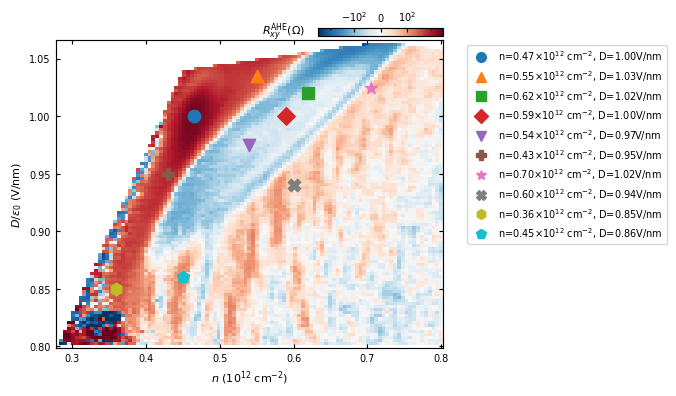

In [7]:
fig = plt.figure(figsize=(5,4))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=-3000, vmax=3000)
plot = guide_map(fig, ax, norm, cmap="RdBu_r", ah_index=ah_index)

pos = ax.get_position()
cb_width = 0.25 
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[-100, 0, 100], \
                  orientation='horizontal')
cb.ax.annotate('$R_{xy}^{\mathrm{AHE}} (\Omega) $', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

# AH hysteresis loop

In [11]:
def plot_hysteresis(fig, axarr, file_id=1564, color="r"):
    files = [file_id, file_id + 1]

    contact_pairs = {
        'curr': {'indices': [], 'norm': colors.Normalize(vmin=0, vmax=1), 'cmap': 'viridis', 'label': r'$I/I_0$'},
        'long1': {'indices': [1,2], 'norm': colors.SymLogNorm(linthresh=10, vmin=-3E4, vmax=3E4), 'cmap': 'RdBu_r', 'label': r'$R_{xx}$ ($\Omega$)'},
        'fakehall': {'indices': [3], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-5E3, vmax=5E3), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
        'realhall': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
        'nl': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
     }
    
    gates = True
    
    color = ['tab:blue', 'tab:red']
    ls = ['-', '-']
    labels = ['Up', 'Down']
    plot_ind = 0
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for i, file in enumerate(files):
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs = data['xs']
        
                if pair=='curr':
                    I = data['sr830_4_X']
                    zs= I
                    zs_arr.append(zs)
                else:
                    I = data['sr830_4_X']
                    Vxx = data[f'sr830_{ind}_X']
                    zs = Vxx/I
                    
                    mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                    zs = np.ma.array(zs, mask=mask)
                plot = axarr[plot_ind].plot(xs[:len(zs)], zs/1e3, color=color[i], ls=ls[i], label=labels[i])
                ax = axarr[plot_ind]
                #ax.legend(loc=(0.6,0.65))
                ax.set_xlabel("$B$(T)")
                ax.set_ylabel("$R$ (k$\Omega$)")
                ax.xaxis.set_major_locator(plt.MaxNLocator(5))
                ax.yaxis.set_major_locator(plt.MaxNLocator(3))
            plot_ind += 1

    return

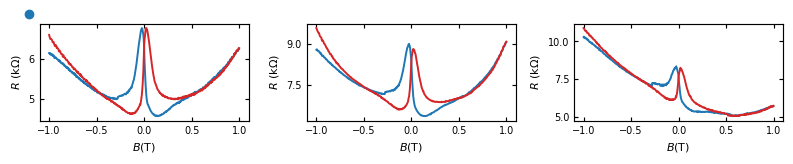

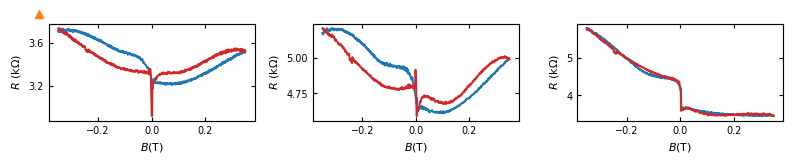

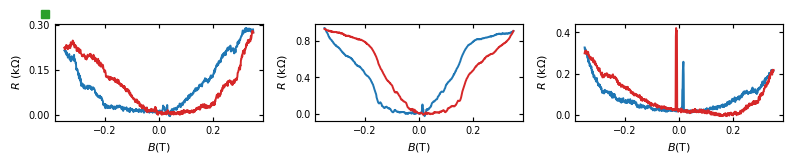

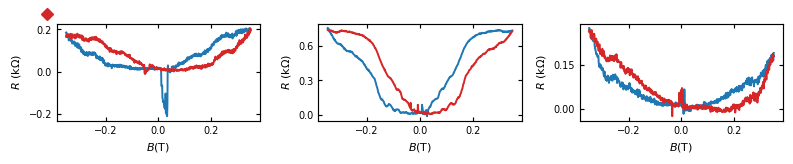

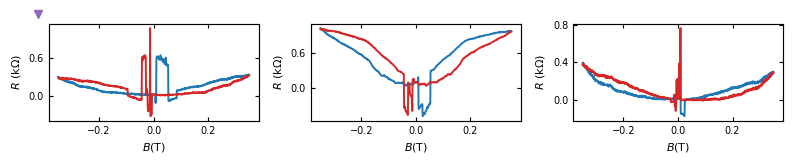

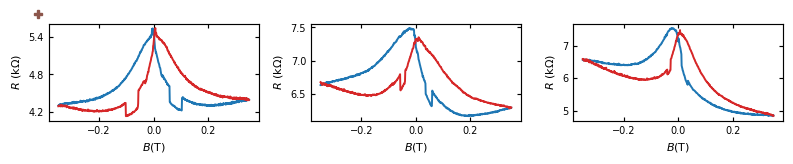

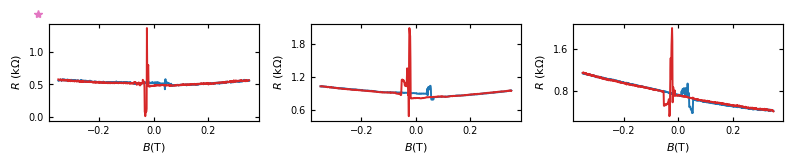

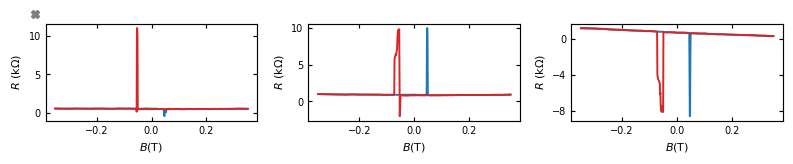

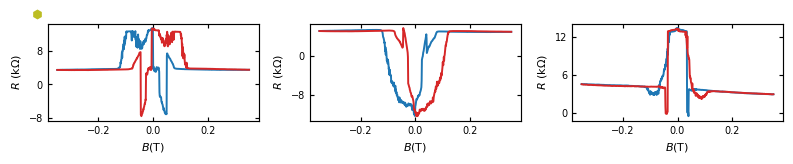

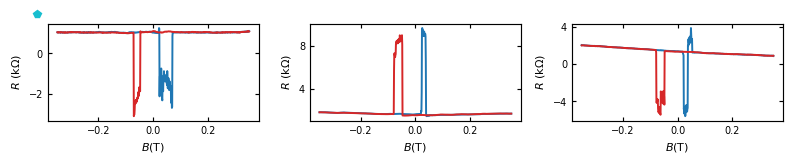

In [12]:
for ah_ind, (n,D,file_id) in enumerate(ah_index):
    fig, axarr = plt.subplots(1,3,figsize=(8,1.75))
    plot_hysteresis(fig, axarr, file_id)
    axarr[0].plot(-0.05, 1.1, marker=markers[ah_ind], markersize=6, color=marker_colors[ah_ind],
            transform=axarr[0].transAxes, clip_on=False)
    plt.tight_layout()

# Full figure at base temp

In [13]:
# n, D, file_id
# comment out the ones not required
ah_index =[
    [0.465, 1.000, 1552],
    #[0.500, 1.025, 1554],
    #[0.550, 1.035, 1556],
    #[0.600, 1.040, 1558],
    #[0.650, 1.046, 1560],
    #[0.620, 1.020, 1562],
    [0.590, 1.000, 1564],
    #[0.540, 0.975, 1566],
    #[0.430, 0.950, 1568],
    #[0.385, 0.900, 1570],
    #[0.475, 0.940, 1572],
    #[0.705, 1.025, 1574],
    [0.600, 0.940, 1576],
    [0.450, 0.900, 1578],
    #[0.450, 0.860, 1582],
    [0.360, 0.850, 1580],
    #[0.500, 0.900, 1584],
    [0.650, 0.900, 1586],
]
markers = ['o', '^', 's', 'D', 'v', 'P', '*', 'X', 'h', 'p', '<', '>', 'H', 'd', '8', '+', 'x', '|']
marker_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_61251/3020878774.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


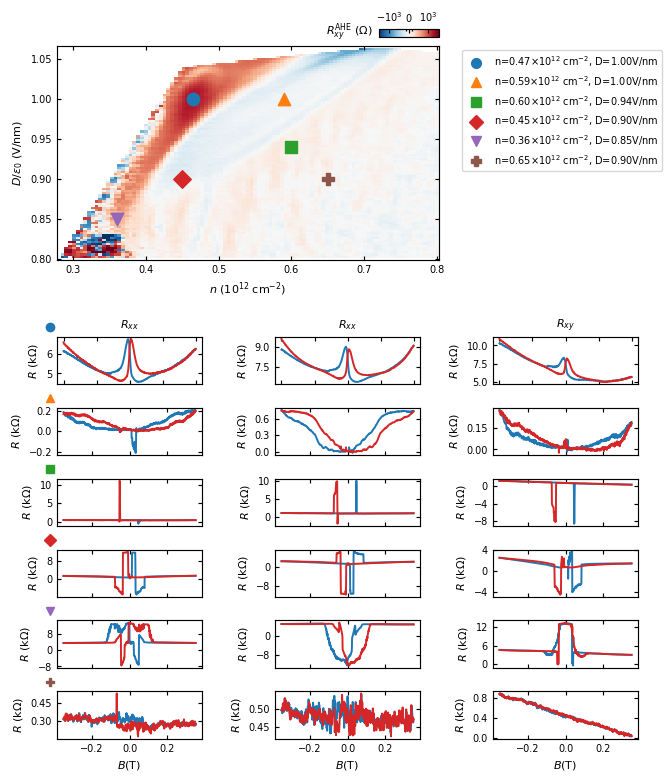

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_61251/3020878774.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [15]:
# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 9))

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

# Outer: 2 rows — top map, bottom block
gs_outer = GridSpec(2, 2, figure=fig,
                    height_ratios=[0.8, len(ah_index)*0.25],
                    width_ratios=[1.3, 0.5],
                    hspace=0.25)
# Inner: tight spacing for the data rows
gs_inner = GridSpecFromSubplotSpec(len(ah_index), 3,
                                   subplot_spec=gs_outer[1, :],
                                   hspace=0.5, wspace=0.5)

################ Panel a ##################
ax = fig.add_subplot(gs_outer[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04

norm = colors.SymLogNorm(linthresh=500, vmin=-6000, vmax=6000)
plot = guide_map(fig, ax, norm, cmap="RdBu_r", ah_index=ah_index)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
cb.ax.annotate(r'$R_{xy}^{\mathrm{AHE}}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

for ah_ind, (n, D, file_id) in enumerate(ah_index):
    axarr = [fig.add_subplot(gs_inner[ah_ind, 0]),
             fig.add_subplot(gs_inner[ah_ind, 1]),
             fig.add_subplot(gs_inner[ah_ind, 2])]
    plot_hysteresis(fig, axarr, file_id)
    axarr[0].plot(-0.05, 1.2, marker=markers[ah_ind], markersize=6, color=marker_colors[ah_ind],
                  transform=axarr[0].transAxes, clip_on=False)
    if ah_ind != len(ah_index) - 1:
        for ax in axarr:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)
    if ah_ind == 0:
        axarr[0].set_title("$R_{xx}$")
        axarr[1].set_title("$R_{xx}$")
        axarr[2].set_title("$R_{xy}$")
    plt.tight_layout()

plt.show()
fig.tight_layout()
fig.savefig("ed-fig-AH-hysteresis.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

# AH map - 500mK

In [19]:
hot_ah_index = [
 [0.465, 1.000, 1600],
 #[0.600, 1.040, 1602],
 #[0.650, 1.046, 1604],
 #[0.620, 1.020, 1606],
 [0.590, 1.000, 1608],
 #[0.540, 0.975, 1610],
 #[0.705, 1.025, 1612],
 [0.600, 0.940, 1614],
 [0.450, 0.900, 1616],
 [0.360, 0.850, 1590],
 #[0.500, 0.900, 1592],
 [0.650, 0.900, 1594],
]

In [20]:
def guide_map_500mK(fig, ax, norm, cmap, ah_index, markers=markers, marker_colors=marker_colors):
    files= [1618, 1619, 1620, 1621]

    ns = np.array([0.45, 0.72, 0.8, 0.8, 0.28])
    Ds = np.array([1.04, 1.065, 1.058, 0.80, 0.80])

    nx, ny = 101, 101

    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)

    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)

    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)

    contact_pairs = {
        'curr': {'indices': [], 'norm': colors.Normalize(vmin=0, vmax=0.5), 'cmap': 'viridis', 'label': r'$I/I_0$'},
        'long1': {'indices': [], 'norm': colors.SymLogNorm(linthresh=10, vmin=0, vmax=3E4), 'cmap': 'viridis', 'label': r'$R_{xx}$ ($\Omega$)'},
        'fakehall': {'indices': [2], 'norm': norm, 'cmap': cmap, 'label': r'$R_{yx}$ ($\Omega$)'},
        'realhall': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E5, vmax=1E5), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
        'nl': {'indices': [], 'norm': colors.SymLogNorm(linthresh=3E4, vmin=-1E2, vmax=1E2), 'cmap': 'RdBu_r', 'label': r'$R_{yx}$ ($\Omega$)'},
    }

    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            
            zss = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 0, rev_x=False, rev_y=True)
                zss.append(zs)

            rxy100 = (zss[1] - zss[2])/2 # 100 mT
            rxy200 = (zss[0] - zss[3])/2 # 200 mT
            # zs_s = (zss[1] + zss[2])/2 - (zss[0] + zss[3])/4
            # zs_a = ((zss[1] - zss[2])/2 - (zss[0] - zss[3])/4)
            zs_a = (rxy100 - (1/2)*rxy200)*2
    
            plot = ax.pcolormesh(xs, ys, zs_a, norm=norm, cmap=cmap, rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')

            for i,(n,D,f) in enumerate(ah_index):
                ax.scatter(n, D, marker=markers[i % len(markers)], color=marker_colors[i % len(marker_colors)], s=80, zorder=3)
                #ax.plot(n, D, 'k.', markersize=12)
                #ax.plot(n, D, 'w.')

                legend_handles = [
                    mlines.Line2D([], [], color=marker_colors[i % len(marker_colors)], marker=markers[i % len(markers)],
                                  linestyle='None', markersize=7, label=f'n={n:.2f}' + r"$\times 10^{12}$ $\mathrm{cm^{-2}}$" 
                                  +  f', D={D:.2f}' + r'V/nm' )
                    for i, (n, D, file) in enumerate(ah_index)
                ]
            
            ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left',
                       frameon=True)
            
    return plot

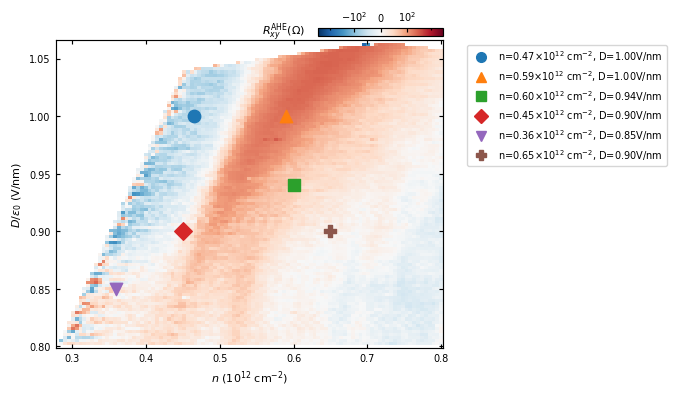

In [21]:
fig = plt.figure(figsize=(5,4))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=-3000, vmax=3000)
plot = guide_map_500mK(fig, ax, norm, cmap="RdBu_r", ah_index=hot_ah_index)

pos = ax.get_position()
cb_width = 0.25 
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[-100, 0, 100], \
                  orientation='horizontal')
cb.ax.annotate('$R_{xy}^{\mathrm{AHE}} (\Omega) $', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')   

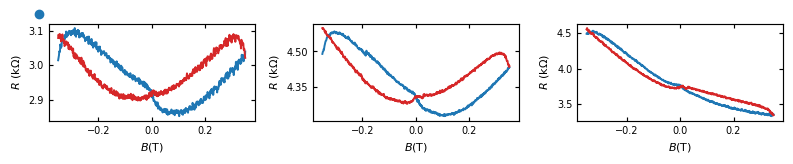

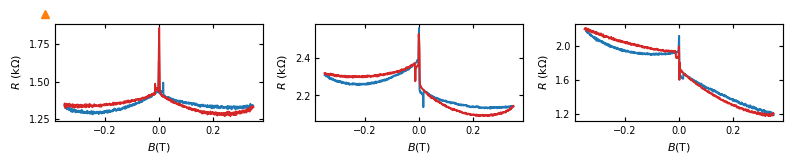

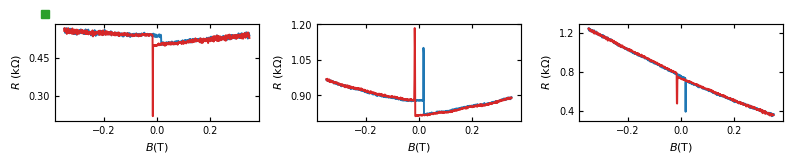

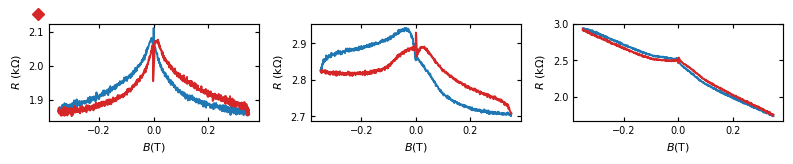

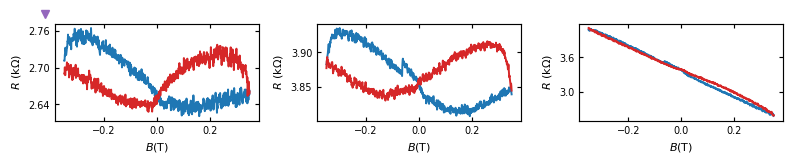

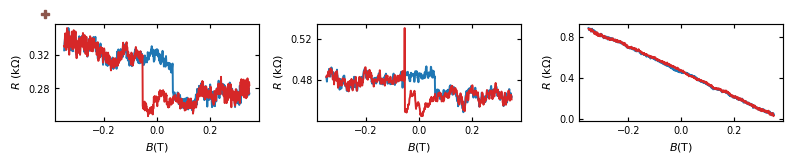

In [22]:
for ah_ind, (n,D,file_id) in enumerate(hot_ah_index):
    fig, axarr = plt.subplots(1,3,figsize=(8,1.75))
    plot_hysteresis(fig, axarr, file_id)
    axarr[0].plot(-0.05, 1.1, marker=markers[ah_ind], markersize=6, color=marker_colors[ah_ind],
            transform=axarr[0].transAxes, clip_on=False)
    plt.tight_layout()

# Full figure

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_61251/952942586.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


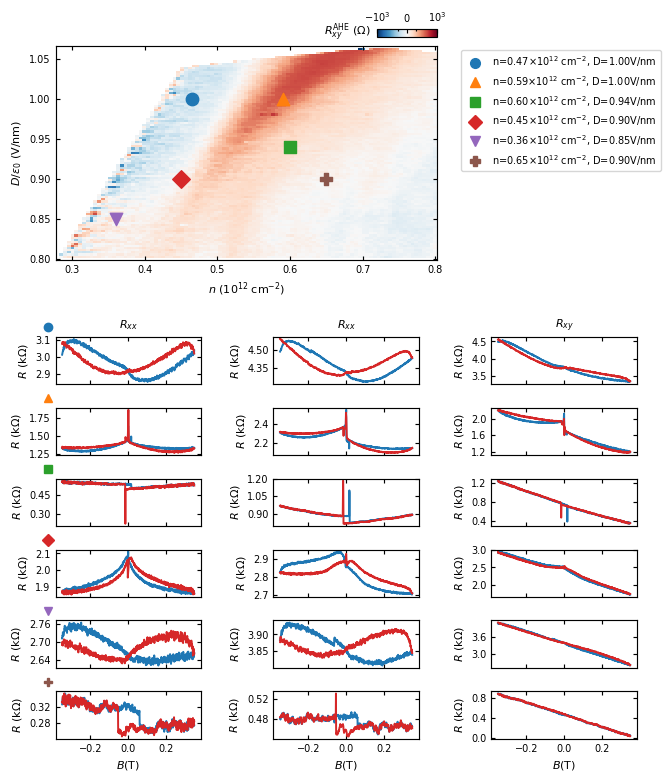

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_61251/952942586.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [23]:
# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 9))

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

# Outer: 2 rows — top map, bottom block
gs_outer = GridSpec(2, 2, figure=fig,
                    height_ratios=[0.8, len(ah_index)*0.25],
                    width_ratios=[1.3, 0.5],
                    hspace=0.25)
# Inner: tight spacing for the data rows
gs_inner = GridSpecFromSubplotSpec(len(ah_index), 3,
                                   subplot_spec=gs_outer[1, :],
                                   hspace=0.5, wspace=0.5)

################ Panel a ##################
ax = fig.add_subplot(gs_outer[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04

norm = colors.SymLogNorm(linthresh=200, vmin=-1000, vmax=1000)
plot = guide_map_500mK(fig, ax, norm, cmap="RdBu_r", ah_index=ah_index)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
cb.ax.annotate(r'$R_{xy}^{\mathrm{AHE}}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

for ah_ind, (n, D, file_id) in enumerate(hot_ah_index):
    axarr = [fig.add_subplot(gs_inner[ah_ind, 0]),
             fig.add_subplot(gs_inner[ah_ind, 1]),
             fig.add_subplot(gs_inner[ah_ind, 2])]
    plot_hysteresis(fig, axarr, file_id)
    axarr[0].plot(-0.05, 1.2, marker=markers[ah_ind], markersize=6, color=marker_colors[ah_ind],
                  transform=axarr[0].transAxes, clip_on=False)
    if ah_ind != len(ah_index) - 1:
        for ax in axarr:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)
    if ah_ind == 0:
        axarr[0].set_title("$R_{xx}$")
        axarr[1].set_title("$R_{xx}$")
        axarr[2].set_title("$R_{xy}$")
    plt.tight_layout()

plt.show()
fig.tight_layout()
fig.savefig("ed-fig-AH-hysteresis-500mK.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

In [328]:
def invert_convertND(D, N, C=.8056e16):
    '''
    Invert convertND:
    Convert from electron density N (10^-12 cm^-2) and displacement
    field D (V/nm) back to gate voltage units (p0, n0).

    C is geometric capacitance in m^-2 V^-1.
    '''
    ee = 1.602176634e-19  # C
    epsilon0 = 8.854187817e-12  # F/m

    k = C * ee / (2 * epsilon0) * 1e-9  # V/nm per p0

    n0 = N / (C * 1.0e-16)
    p0 = D / k

    return p0, n0

In [331]:
invert_convertND(1, 0.9)

(13.71983455977791, 1.1171797418073486)